In [1]:
req_ratios = [1, 1.25, 1.5, 1.75, 2]
sched_paths = [f"sched_request{x}_threshold07" for x in req_ratios]
offloading_paths = [f"offloading_request{x}_threshold07" for x in req_ratios]
native_paths = [f"native_request{x}_threshold07" for x in req_ratios]

In [2]:
import json

import numpy as np


def load_metric(path):
    fp = open(f"../tmp/{path}.json")
    data = json.load(fp)
    fp.close()
    raw = data["raw"]
    statics = data["statics"]
    data = {
        "ttft": raw["TTFT_TEE"],
        "tpot": raw["TPOT_TEE"],
        "ttft_slo": raw["TTFT_SLO_TEE"],
        "latency": raw["LATENCY_TEE"],
        "finish_time": max(raw["FINISH_TIME_TEE"]),
    }
    data = {k: np.array(v) for (k, v) in sorted(data.items())}
    return data

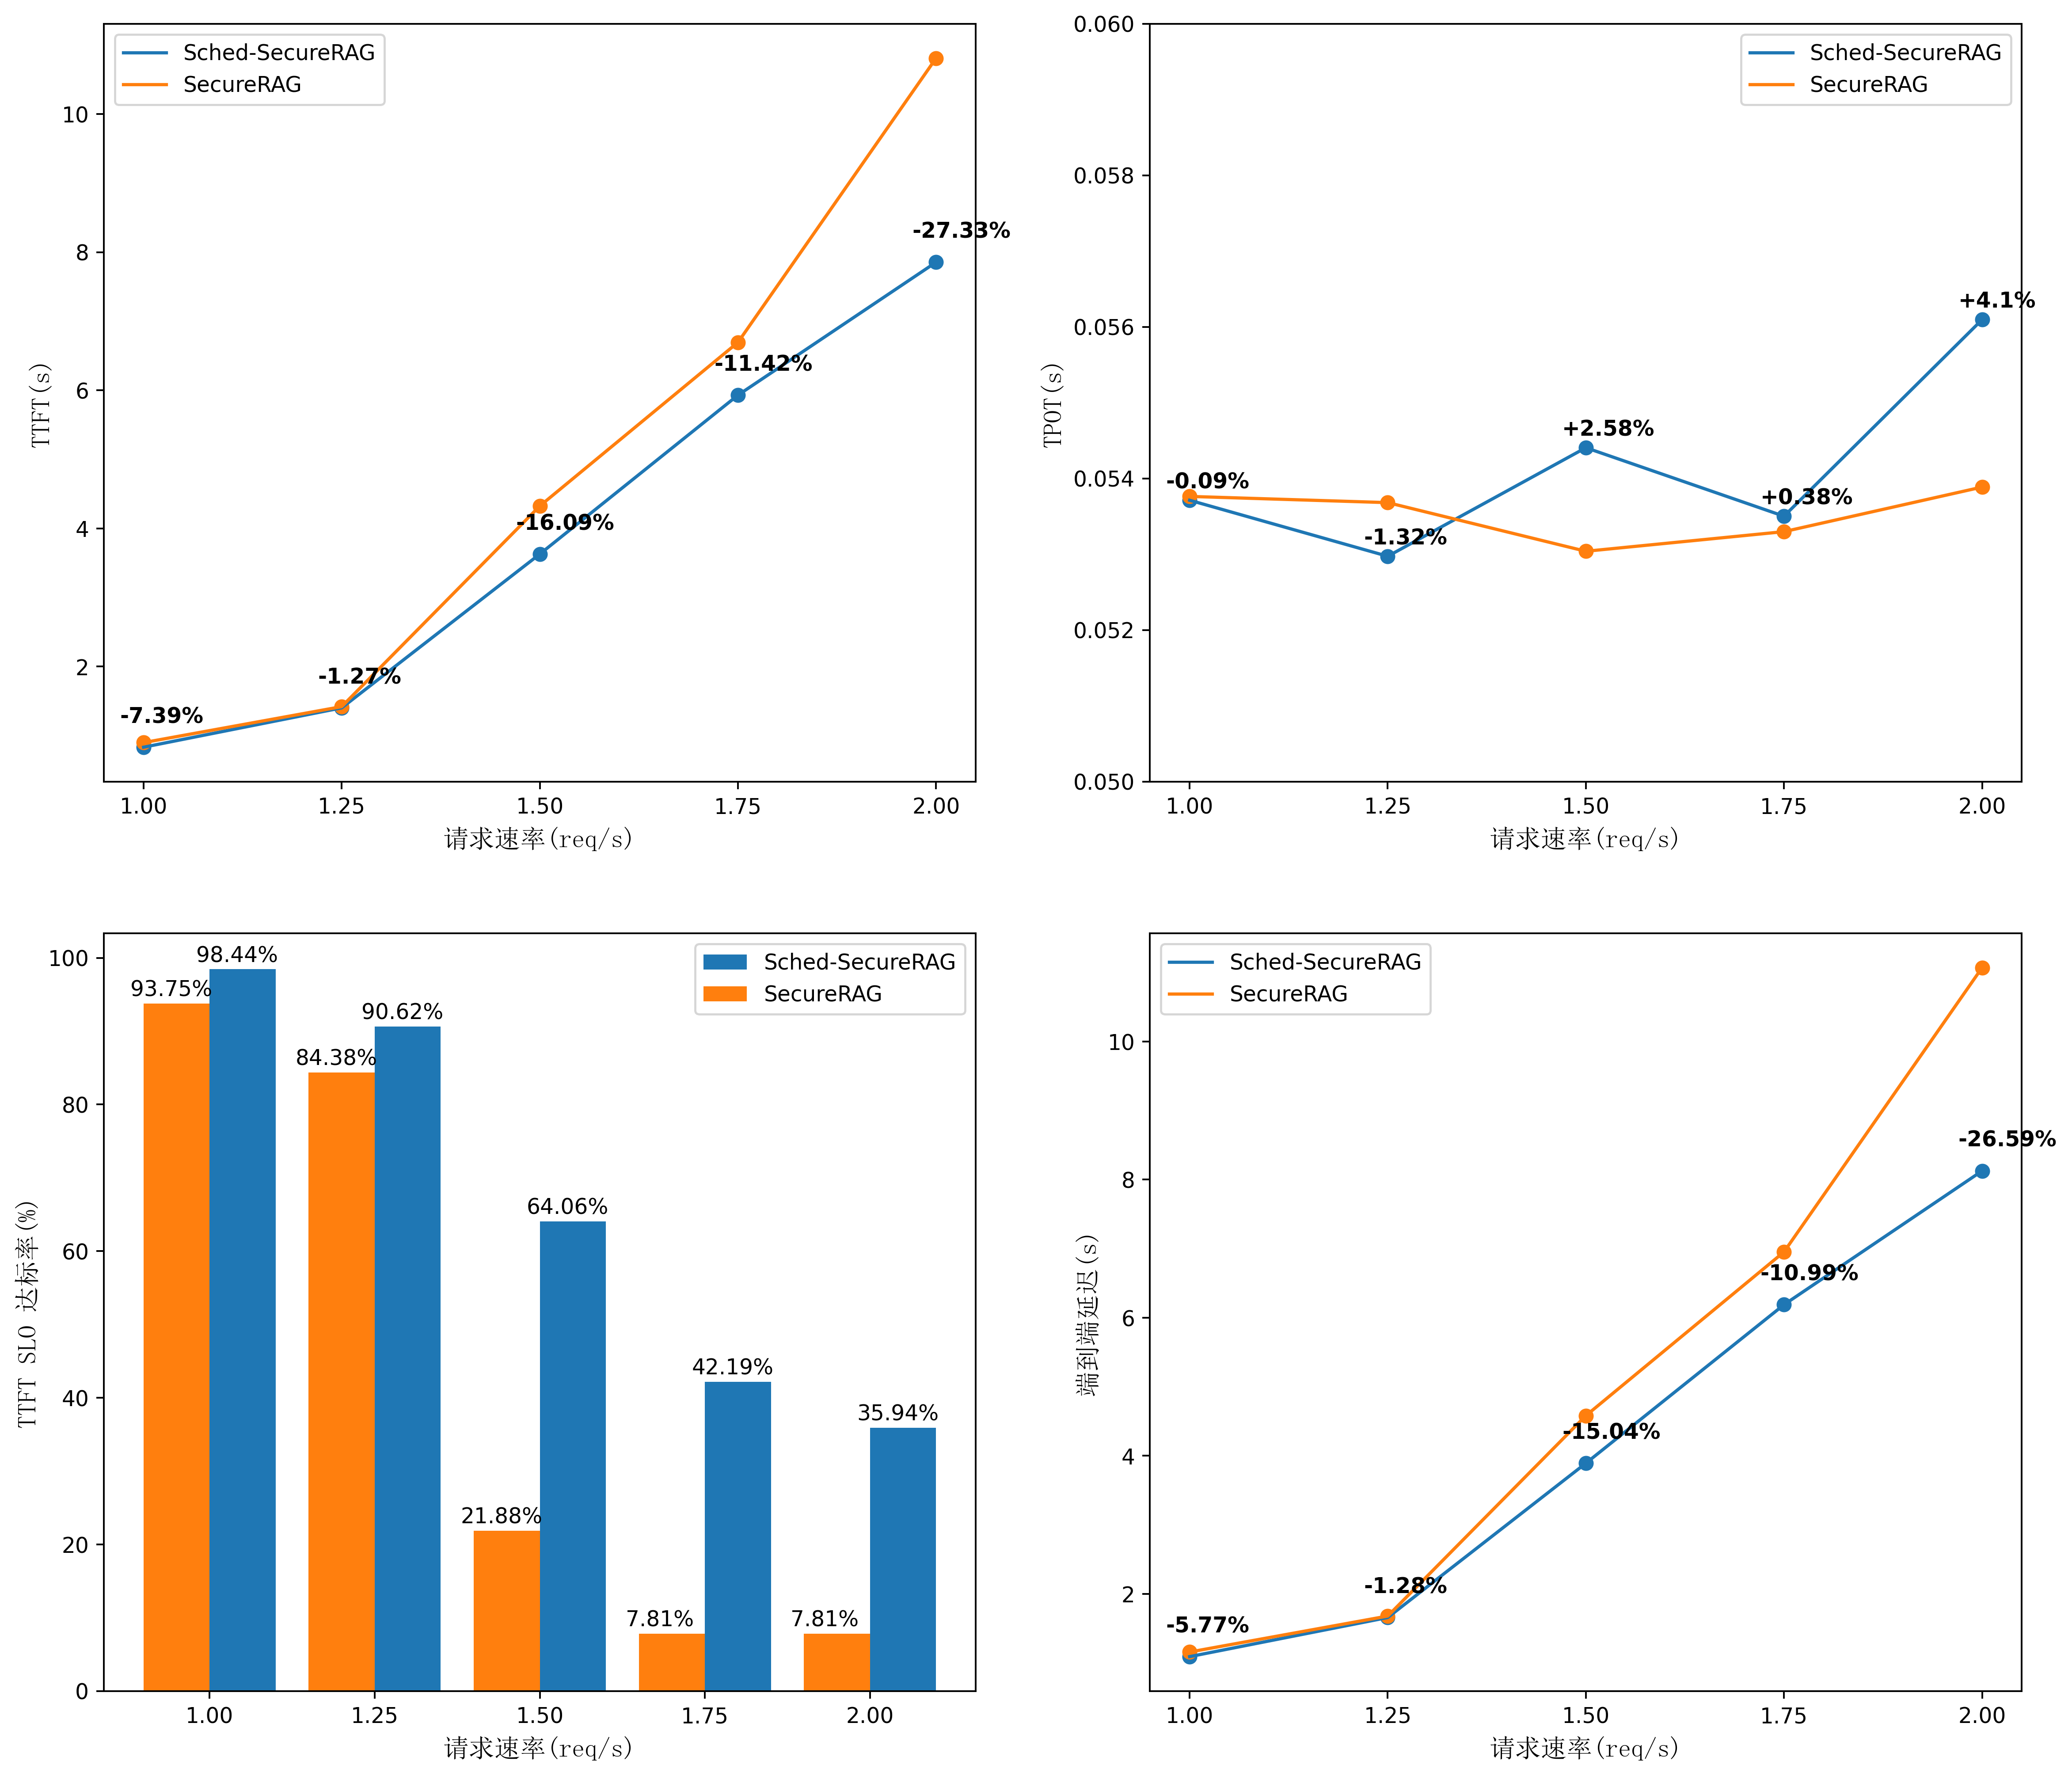

In [3]:
import os
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)

fig, axes = plt.subplots(2, 2, figsize=(16, 14), dpi=350)
all_metric = []
for label, paths in zip(
    ["Sched-SecureRAG", "SecureRAG"], [sched_paths, offloading_paths]
):
    ttft = []
    tpot = []
    ttft_slo = []
    latency = []
    for idx, ratio in enumerate(req_ratios):
        metric = load_metric(paths[idx])
        ttft.append(metric["ttft"].mean())
        tpot.append(metric["tpot"].mean())
        latency.append(metric["latency"].mean())
        ttft_slo.append(metric["ttft_slo"].sum() / 64)
    all_metric.append([ttft, tpot, ttft_slo, latency])

all_metric = [[np.array(x) for x in m] for m in all_metric]
# [
# Sched: [[ttft], ...]
# Secure: [[ttft], ...]
# ]

ratio = []
for i in range(4):
    ratio.append((all_metric[1][i] - all_metric[0][i]) / all_metric[1][i] * 100)


for label, metric in zip(["Sched-SecureRAG", "SecureRAG"], all_metric):
    for idx, (y, y_label, ax) in enumerate(
        zip(
            metric,
            ["TTFT", "TPOT", "TTFT SLO", "端到端延迟"],
            axes.flatten(),
        )
    ):
        x = req_ratios
        if y_label == "TTFT SLO":
            if label == "SecureRAG":
                x = np.array(x) - 0.05
            else:
                x = np.array(x) + 0.05
            y = np.array(y).round(4) * 100
            ax.bar(x, y, width=0.1, label=label)
            ax.set_ylabel(f"{y_label} 达标率(%)", fontproperties=font)
            for a, b in zip(x, y):
                ax.text(a - 0.07, b + 1, f"{round(b,4)}%")
        else:
            ax.plot(x, y, label=label)
            ax.scatter(x, y)
            ax.set_ylabel(f"{y_label}(s)", fontproperties=font)
            if label == "Sched-SecureRAG":
                pad = 0.05 * (y.max() - y.min())
                for r, (a, b) in enumerate(zip(x, y)):
                    ax.text(
                        a - 0.03,
                        b + pad,
                        f"{'+'if ratio[idx][r] < 0 else ''}{-1 * round(ratio[idx][r], 2)}%",
                        fontweight="bold",
                    )
            if idx == 1:
                ax.set_ylim(0.050, 0.06)
        ax.set_xlabel("请求速率(req/s)", fontproperties=font)
        ax.legend()
        ax.set_xticks(req_ratios)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

cores = np.linspace(0, 20, 11, dtype=int)
tee_core_paths = [f"../tmp/tee_core_{x}.json" for x in cores]
tee_core_metrics = []

def load_metric():
    for path in tee_core_paths:
        fp = open(path)
        data = json.load(fp)
        cpu_decoder_time = data["statics"]["cpu_DECODER(statics)"]
        cpu_encoder_time = data["statics"]["cpu_ENCODER(statics)"]
        tee_core_metrics.append([cpu_decoder_time[0], cpu_encoder_time[0]])
        fp.close()
load_metric()

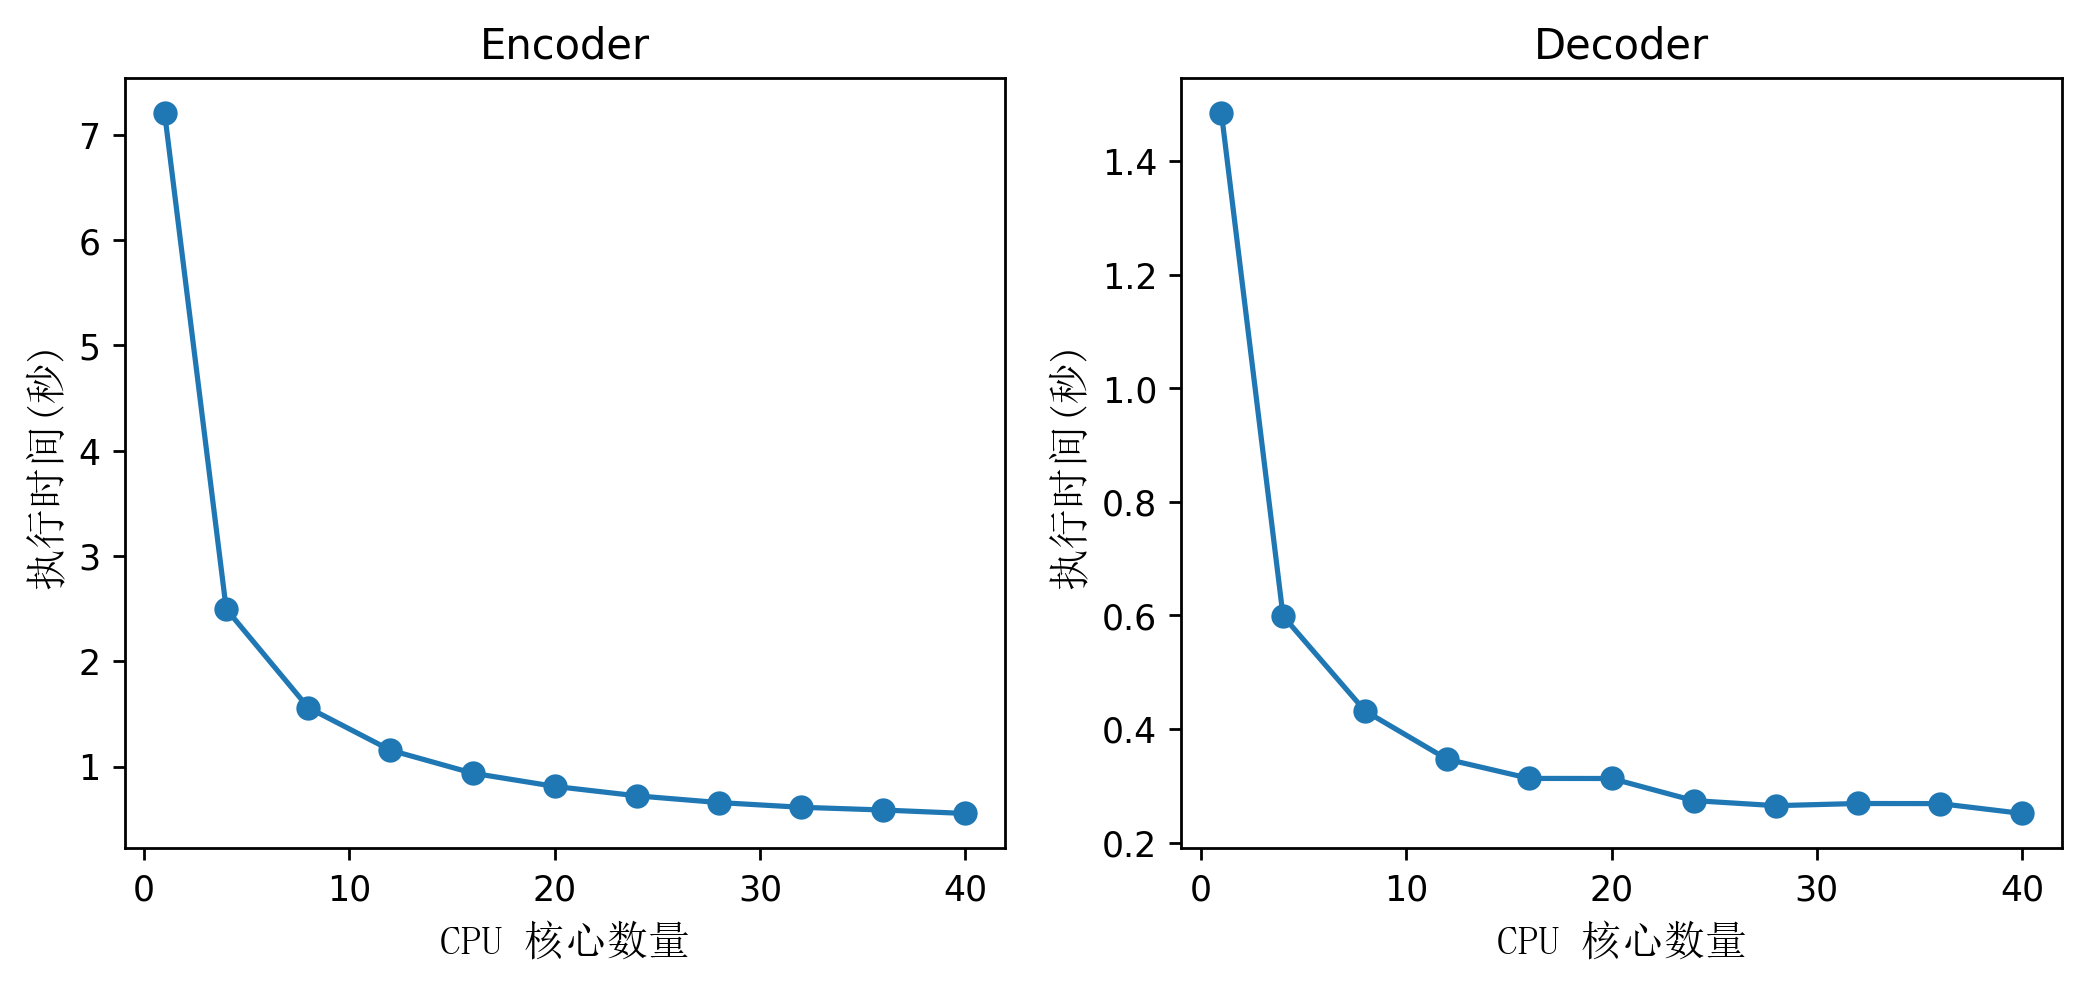

In [32]:
def plot_core():
    global tee_core_metrics
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)

    tee_core_metrics = np.array(tee_core_metrics)
    x = np.array(cores) * 2
    x[0] = 1
    y_decoder = tee_core_metrics[:, 0].squeeze()
    y_encoder = tee_core_metrics[:, 1].squeeze()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=250)
    for ax, tag, y in zip(axes.flatten(), ["Encoder", "Decoder"], [y_encoder, y_decoder]):
        ax.plot(x, y, label=tag)
        ax.scatter(x, y)
        # ax.set_xticks(x)
        ax.set_title(tag)
        ax.set_ylabel("执行时间(秒)", fontproperties=font)
        ax.set_xlabel("CPU 核心数量", fontproperties=font)

plot_core()